In [1]:
# Importing all libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Loading and preparing the dataset same as question 1
df = pd.read_csv('tech_roles_trends.csv')
df['Week'] = pd.to_datetime(df['Week'])
df.set_index('Week', inplace=True)
df.sort_index(inplace=True)

print(" Data loaded and prepared!")
print("Shape:", df.shape)
df.head()

 Data loaded and prepared!
Shape: (262, 3)


,Data Analyst,Software Engineer,Cybersecurity Specialist
Week,,,
2019-04-21,55,55,18
2019-04-28,52,50,16
2019-05-05,56,56,17
2019-05-12,56,61,18
2019-05-19,57,56,17


##  Training and Test Split

In [3]:
# Splitting data into 80% train and 20% test
# 262 weeks total — last 52 weeks whcih is 1 year for testing
train = df.iloc[:-52]
test = df.iloc[-52:]

print(" Train/Test split complete!")
print(f"Training set: {train.shape[0]} weeks ({train.index.min().date()} to {train.index.max().date()})")
print(f"Testing set: {test.shape[0]} weeks ({test.index.min().date()} to {test.index.max().date()})")

 Train/Test split complete!
Training set: 210 weeks (2019-04-21 to 2023-04-23)
Testing set: 52 weeks (2023-04-30 to 2024-04-21)


##  Model Selection — ACF and PACF Analysis

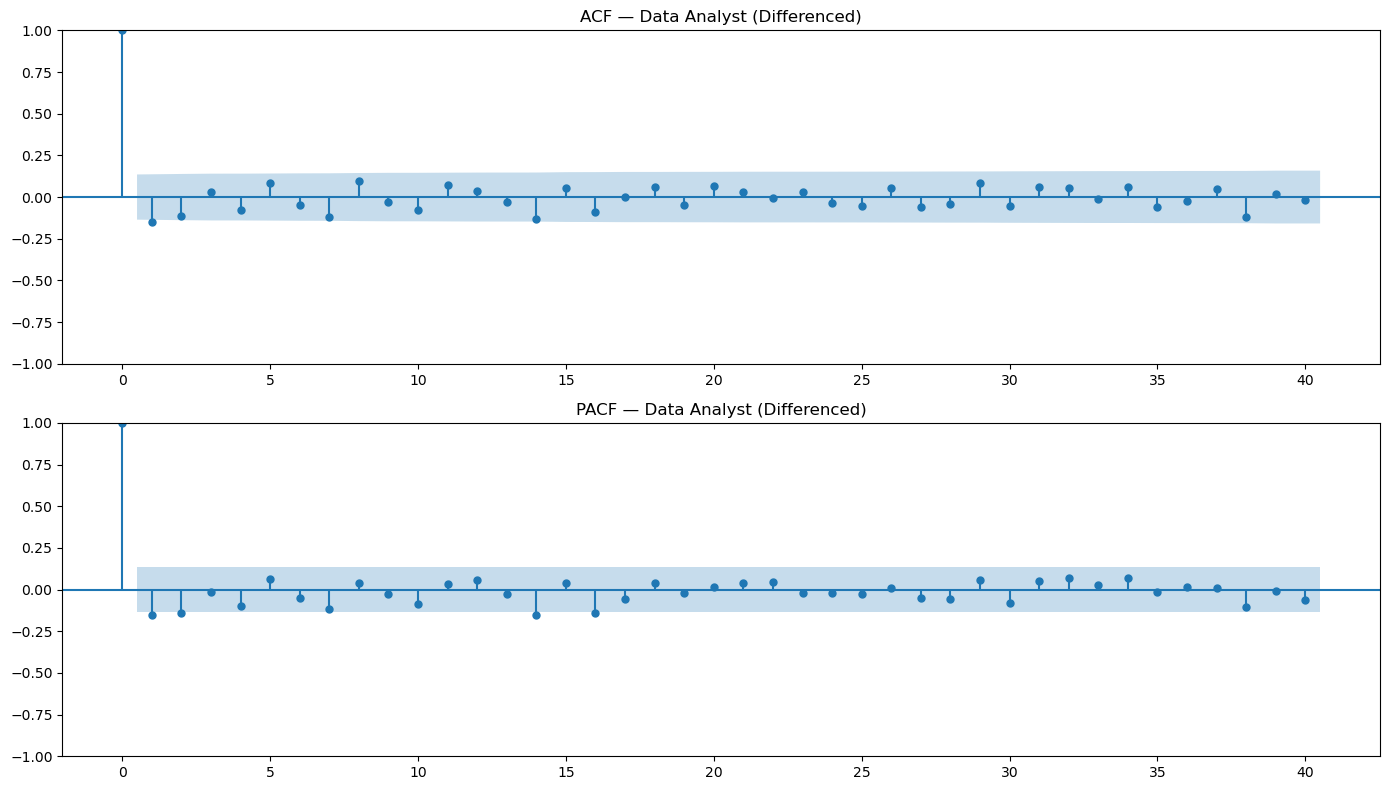

In [4]:
# Plotting ACF and PACF for Data Analyst
# Data Analyst needs differencing (d=1) from Question 1
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(train['Data Analyst'].diff().dropna(), lags=40, ax=axes[0], title='ACF — Data Analyst (Differenced)')
plot_pacf(train['Data Analyst'].diff().dropna(), lags=40, ax=axes[1], title='PACF — Data Analyst (Differenced)')
plt.tight_layout()
plt.show()

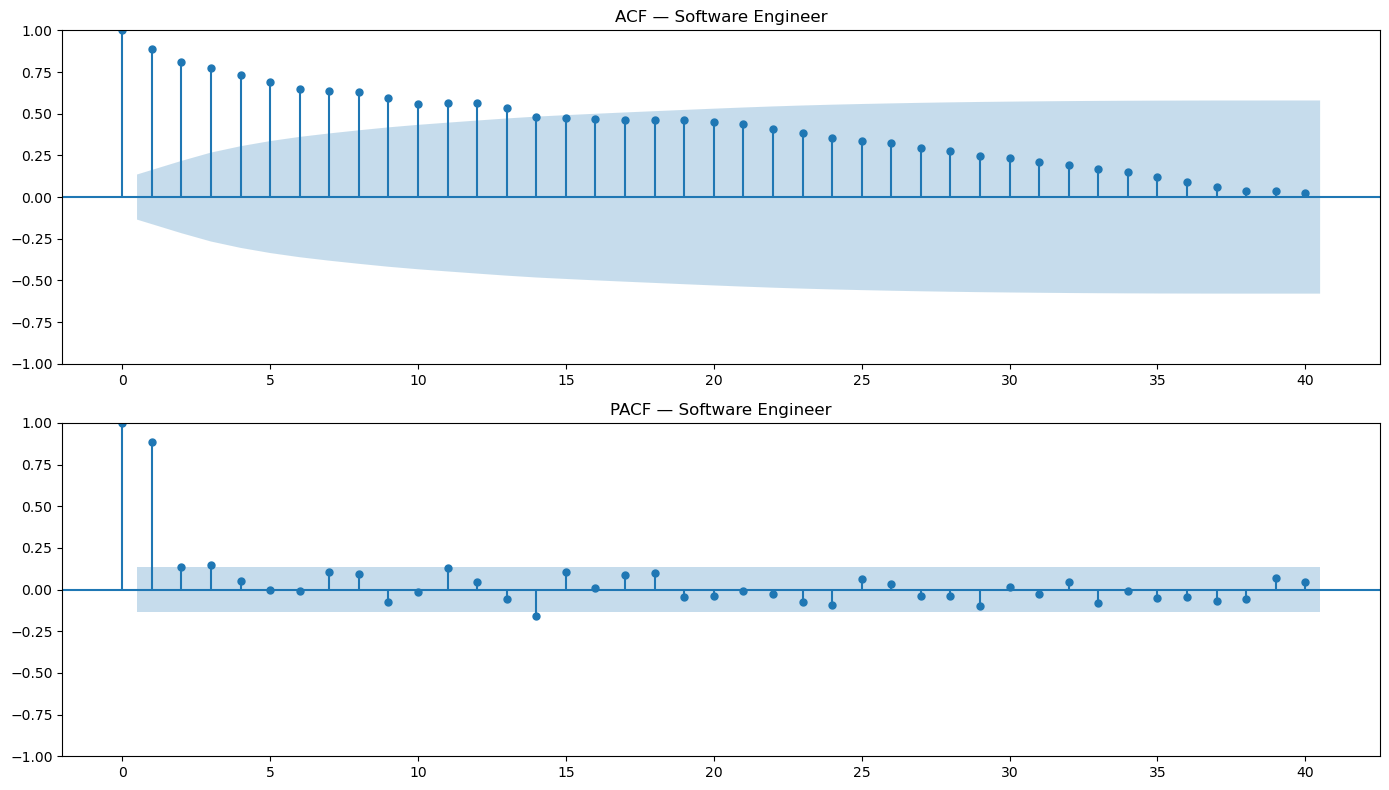

In [5]:
# Plotting ACF and PACF for Software Engineerr
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(train['Software Engineer'], lags=40, ax=axes[0], title='ACF — Software Engineer')
plot_pacf(train['Software Engineer'], lags=40, ax=axes[1], title='PACF — Software Engineer')
plt.tight_layout()
plt.show()

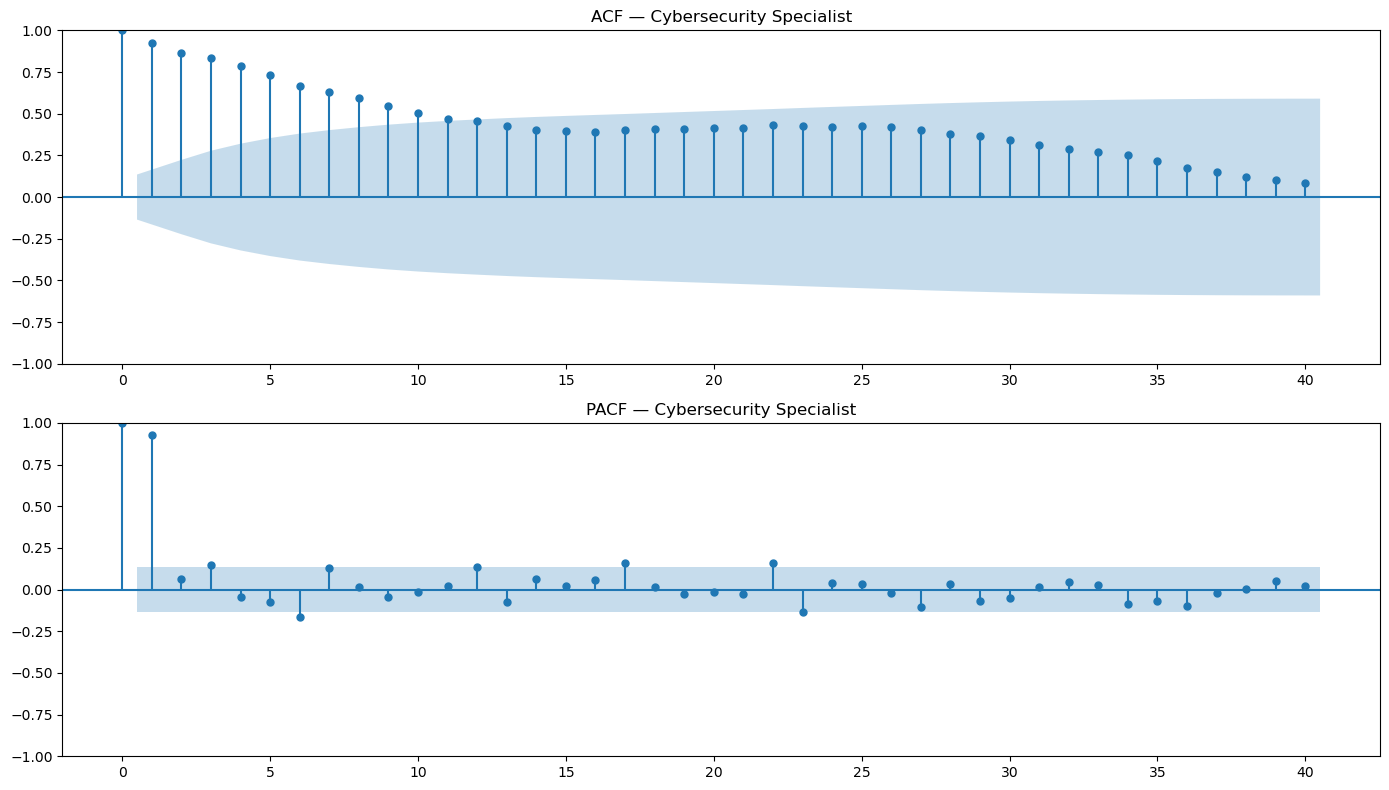

In [6]:
# Plotting ACF and PACF for Cybersecurity Specialist
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(train['Cybersecurity Specialist'], lags=40, ax=axes[0], title='ACF — Cybersecurity Specialist')
plot_pacf(train['Cybersecurity Specialist'], lags=40, ax=axes[1], title='PACF — Cybersecurity Specialist')
plt.tight_layout()
plt.show()

##  Model Fitting

In [7]:
# Fitting ARIMA(1,1,1) for Data Analyst
print("Fitting ARIMA model for Data Analyst...")
model_da = ARIMA(train['Data Analyst'], order=(1,1,1))
result_da = model_da.fit()
print(result_da.summary())

Fitting ARIMA model for Data Analyst...
                               SARIMAX Results                                
Dep. Variable:           Data Analyst   No. Observations:                  210
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -618.847
Date:                Sun, 24 May 2026   AIC                           1243.693
Time:                        13:45:43   BIC                           1253.720
Sample:                    04-21-2019   HQIC                          1247.747
                         - 04-23-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5821      0.155      3.757      0.000       0.278       0.886
ma.L1         -0.7538      0.130     -5.801      0.000      -1.008      -0.499
sigma2      

In [8]:
# Fitting ARIMA(1,0,1) for Software Engineer
print("Fitting ARIMA model for Software Engineer...")
model_se = ARIMA(train['Software Engineer'], order=(1,0,1))
result_se = model_se.fit()
print(result_se.summary())

Fitting ARIMA model for Software Engineer...
                               SARIMAX Results                                
Dep. Variable:      Software Engineer   No. Observations:                  210
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -552.868
Date:                Sun, 24 May 2026   AIC                           1113.736
Time:                        13:46:40   BIC                           1127.125
Sample:                    04-21-2019   HQIC                          1119.149
                         - 04-23-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.6517      2.527     19.648      0.000      44.699      54.605
ar.L1          0.9266      0.031     29.524      0.000       0.865       0.988
ma.L1  

In [9]:
# Fitting ARIMA(1,0,1) for Cybersecurity Specialist
print("Fitting ARIMA model for Cybersecurity Specialist...")
model_cs = ARIMA(train['Cybersecurity Specialist'], order=(1,0,1))
result_cs = model_cs.fit()
print(result_cs.summary())

Fitting ARIMA model for Cybersecurity Specialist...
                                  SARIMAX Results                                   
Dep. Variable:     Cybersecurity Specialist   No. Observations:                  210
Model:                       ARIMA(1, 0, 1)   Log Likelihood                -389.766
Date:                      Sun, 24 May 2026   AIC                            787.533
Time:                              13:46:50   BIC                            800.921
Sample:                          04-21-2019   HQIC                           792.945
                               - 04-23-2023                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.3218      1.667     11.590      0.000      16.054      22.589
ar.L1          0.9370      0.02

In [10]:
# Generating forecasts for all 3 models on the test set
forecast_da = result_da.forecast(steps=52)
forecast_se = result_se.forecast(steps=52)
forecast_cs = result_cs.forecast(steps=52)

print(" Forecasts generated for all 3 of the job roles!")
print("\nData Analyst forecast (first 5 weeks):")
print(forecast_da[:5])

 Forecasts generated for all 3 of the job roles!

Data Analyst forecast (first 5 weeks):
2023-04-30    81.604503
2023-05-07    81.956356
2023-05-14    82.161152
2023-05-21    82.280355
2023-05-28    82.349737
Freq: W-SUN, Name: predicted_mean, dtype: float64


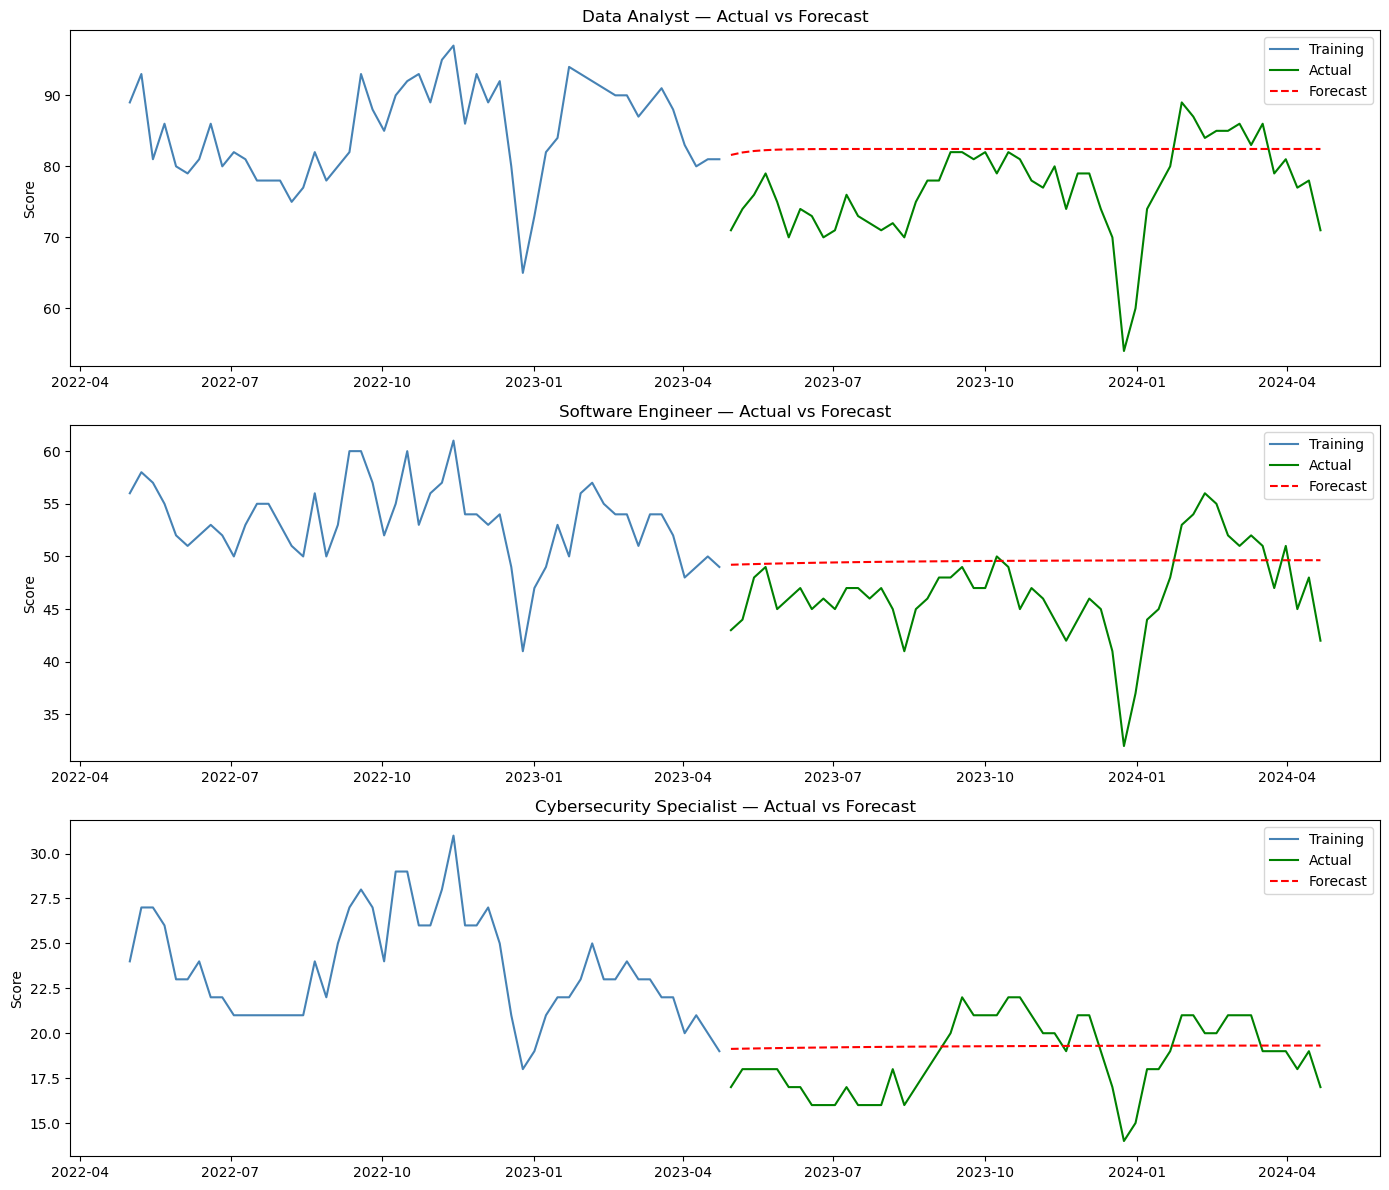

In [11]:
# Plotting forecasted vs actual for all 3 job roles
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# This one is for Data Analyst
axes[0].plot(train.index[-52:], train['Data Analyst'][-52:], color='steelblue', label='Training')
axes[0].plot(test.index, test['Data Analyst'], color='green', label='Actual')
axes[0].plot(test.index, forecast_da, color='red', linestyle='--', label='Forecast')
axes[0].set_title('Data Analyst — Actual vs Forecast')
axes[0].set_ylabel('Score')
axes[0].legend()

# This one is for Software Engineer
axes[1].plot(train.index[-52:], train['Software Engineer'][-52:], color='steelblue', label='Training')
axes[1].plot(test.index, test['Software Engineer'], color='green', label='Actual')
axes[1].plot(test.index, forecast_se, color='red', linestyle='--', label='Forecast')
axes[1].set_title('Software Engineer — Actual vs Forecast')
axes[1].set_ylabel('Score')
axes[1].legend()

# This one is for Cybersecurity Specialist
axes[2].plot(train.index[-52:], train['Cybersecurity Specialist'][-52:], color='steelblue', label='Training')
axes[2].plot(test.index, test['Cybersecurity Specialist'], color='green', label='Actual')
axes[2].plot(test.index, forecast_cs, color='red', linestyle='--', label='Forecast')
axes[2].set_title('Cybersecurity Specialist — Actual vs Forecast')
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.show()